In [ ]:
 !pip install koreanize-matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 65.6 MB/s eta 0:00:00


In [ ]:
import pandas as pd
df = pd.read_csv('earthquake.csv')
df.head()

,시간,규모,진앙(km),위도,경도,위치
0,2014-01-29 6:08:44,2.2,11.0,36.23,128.80,경북 의성군 남동쪽 16km 지역
1,2014-02-05 23:06:01,2.8,7.0,38.26,124.40,북한 황해남도 용연군 장산곶 서북서쪽 29km 해역
2,2014-02-21 21:17:21,2.7,6.0,35.05,127.75,전남 광양시 북북동쪽 13km 지역
3,2014-02-22 20:44:23,2.6,0.0,38.31,124.27,북한 황해남도 용연군 장산곶 서북서쪽 42km 해역
4,2014-02-28 3:20:05,2.4,0.0,38.74,125.01,북한 남포 서쪽 22km 해역


In [ ]:
df.isnull().sum()

,0
시간,0
규모,0
진앙(km),6
위도,0
경도,0
위치,0


In [ ]:
# axis=0: 행 단위, inplace=True: 원본 데이터 프레임 변경
df.dropna(axis=0, inplace=True)

In [ ]:
# pd.to_datetime : 날짜 및 시간 정보를 가진 데이터를 pandas의 datetime 형식으로 변환하기
df['연도'] = pd.to_datetime(df['시간']).dt.year # dt.year : datetime 타입에서 연도만 추출하기
df.head()

,시간,규모,진앙(km),위도,경도,위치,연도
0,2014-01-29 6:08:44,2.2,11.0,36.23,128.80,경북 의성군 남동쪽 16km 지역,2014
1,2014-02-05 23:06:01,2.8,7.0,38.26,124.40,북한 황해남도 용연군 장산곶 서북서쪽 29km 해역,2014
2,2014-02-21 21:17:21,2.7,6.0,35.05,127.75,전남 광양시 북북동쪽 13km 지역,2014
3,2014-02-22 20:44:23,2.6,0.0,38.31,124.27,북한 황해남도 용연군 장산곶 서북서쪽 42km 해역,2014
4,2014-02-28 3:20:05,2.4,0.0,38.74,125.01,북한 남포 서쪽 22km 해역,2014


<Axes: xlabel='연도', ylabel='규모'>

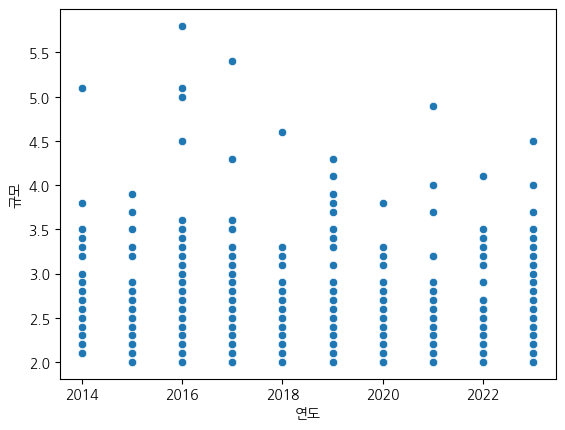

In [ ]:
import koreanize_matplotlib # 한글 깨짐 방지
import seaborn as sns # 그래프 라이브러리
sns.scatterplot(x='연도', y='규모', data=df) # 산점도 그래프

In [ ]:
df['지역']=df['위치'].str[:3]
df['지역']

,지역
0,경북
1,북한
2,전남
3,북한
4,북한
...,...
1077,북한
1078,전남
1079,충남
1080,경북


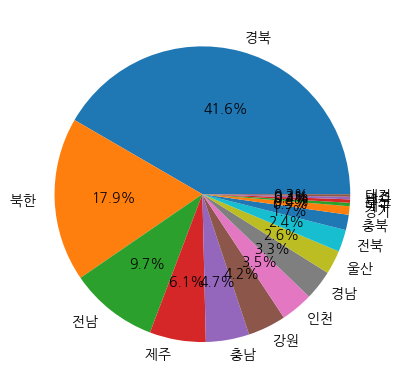

In [ ]:
import matplotlib.pyplot as plt
loc = df['지역'].value_counts() # ‘지역’열 값의 빈도수를 구하기
# 원그래프 시각화, labels : 레이블 지정, autopct : 값을 %로 표시
plt.pie(loc, labels = loc.index, autopct="%1.1f%%")
plt.show()